In [3]:
import torch
import sys
import os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(str(Path(__file__).resolve().parent.parent / "gaussian-splatting"))  # gaussian-splattingを追加

from scene import Scene
from tqdm import tqdm
from os import makedirs
from gaussian_renderer import render
import torchvision
from utils.general_utils import safe_state
from argparse import ArgumentParser
from arguments import ModelParams, PipelineParams, get_combined_args
from gaussian_renderer import GaussianModel
try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False

NameError: name '__file__' is not defined

In [4]:
import torch
import sys
import os
from pathlib import Path

# 現在の作業ディレクトリを確認
print("Current working directory:", os.getcwd())

# パスを追加
sys.path.append("../")
sys.path.append("../gaussian-splatting")

# パスが正しく追加されているか確認
print("Python paths:")
for path in sys.path[-5:]:  # 最後に追加された5つのパスを表示
    print(" -", path)

# gaussian-splattingディレクトリが存在するか確認
gaussian_path = "../gaussian-splatting"
if os.path.exists(gaussian_path):
    print(f"✓ {gaussian_path} exists")
    print("Contents:", os.listdir(gaussian_path)[:10])  # 最初の10ファイルを表示
else:
    print(f"✗ {gaussian_path} does not exist")

# インポートを試行
try:
    from scene import Scene
    print("✓ Successfully imported Scene")
except ImportError as e:
    print(f"✗ Failed to import Scene: {e}")

Current working directory: c:\Users\Maemaeko\imari_lab\r2_gaussian\volunme_slicing_display
Python paths:
 - c:\Users\Maemaeko\imari_lab\r2_gaussian
 - c:\Users\Maemaeko\imari_lab\r2_gaussian
 - c:\Users\Maemaeko\imari_lab\r2_gaussian
 - ../
 - ../gaussian-splatting
✓ ../gaussian-splatting exists
Contents: ['.gitignore', '.gitmodules', 'arguments', 'assets', 'convert.py', 'data', 'environment.yml', 'full_eval.py', 'gaussian-splatting-lightning', 'gaussian_renderer']
✓ Successfully imported Scene


In [7]:
from tqdm import tqdm
from os import makedirs
from gaussian_renderer import render
import torchvision
from utils.general_utils import safe_state
from argparse import ArgumentParser
from arguments import ModelParams, PipelineParams, get_combined_args
from gaussian_renderer import GaussianModel
try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False

In [10]:
from argparse import Namespace
parser = ArgumentParser(description="Testing script parameters")

model = ModelParams(parser, sentinel=True)
pipeline = PipelineParams(parser)

args = Namespace(
    sh_degree = 3,
    model_path="../gaussian-splatting/output/6bd50db1-7",
    source_path="../gaussian-splatting/data/bigfoot",
    images = "images",
    depths = "",
    resolution = -1,
    white_background = False,
    train_test_exp = False,
    data_device = "cuda",
    eval = False,
    debug = False,
    antialiasing = False,
    convert_SHs_python = False,
    compute_cov3D_python = False
)

dataset = model.extract(args)
pipeline = pipeline.extract(args)

gaussians = GaussianModel(dataset.sh_degree)



# Sceneの作成
scene = Scene(dataset, gaussians, load_iteration=-1, shuffle=False)


Loading trained model at iteration 30000
Reading camera 1/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2582.0138469010963 for both axes.
Reading camera 2/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2595.9419245632284 for both axes.
Reading camera 3/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2609.0026778697584 for both axes.
Reading camera 4/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2626.3193412834958 for both axes.
Reading camera 5/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2620.1899792579256 for both axes.
Reading camera 6/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2612.4946906037335 for both axes.
Reading camera 7/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2613.3063885904285 for both axes.
Reading camera 8/69Warning: Colmap camera model SIMPLE_RADIAL n

3_0181.png
0.704232208709321 0.4076177113708152
87


(-0.5, 1599.5, 899.5, -0.5)

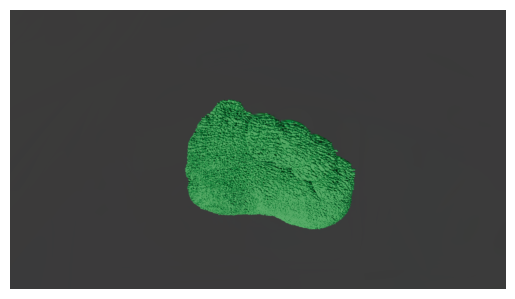

In [12]:
from pathlib import Path
ply_file = Path(r"C:\Users\Maemaeko\imari_lab\r2_gaussian\gaussian-splatting\output\6bd50db1-7\point_cloud\iteration_30000\point_cloud.ply")
scene.gaussians.load_ply(ply_file)
gaussians = scene.gaussians
import matplotlib.pyplot as plt
view = scene.getTrainCameras()[36]
print(view.image_name)
print(view.FoVx, view.FoVy)
print(view.colmap_id)
bg_color = [1,1,1] if dataset.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
rendering = render(view, gaussians, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする